# A string does not contain a boolean — a reader assigns one

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/boolean-parser/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/boolean-parser/demo.ipynb)

**Day 154 of the FDE portfolio.** `"false"` comes back **true** in six of the
sixteen readers below, and that is not a bug in any of them.

A boolean reader is three separate decisions:

1. an **accept table** — which spellings mean true, which mean false;
2. a **normalisation** — case, whitespace, Unicode, applied *before* the lookup;
3. a **failure policy** — refuse, or quietly fall back to one of the two answers.

The word `true` in a config file carries none of them. Sixteen layers each pick
their own three, and the value changes as it crosses them.

**What this notebook does**

| § | |
|---|---|
| 1 | The corpus — 45 strings somebody actually typed |
| 2 | The 16 readers, and re-running as many as *your* machine can |
| 3 | The headline: no string is read the same way by all sixteen |
| 4 | `"false"` → true, six times |
| 5 | Ten of sixteen readers cannot fail |
| 6 | Succeeding is not deciding: the *not-a-boolean* verdict |
| 7 | The Norway problem — YAML 1.1 vs YAML 1.2 |
| 8 | In SQLite the string `'true'` is false (live, on your machine) |
| 9 | `Boolean(s)` and `s == true` are different readers |
| 10 | The file the value travelled in is part of the value |
| 11 | Normalisation: `lower()` and `casefold()` are different functions |
| 12 | The picture |
| 13 | Written for one reader, read by another — and it runs one way |
| 14 | Try your own |

## 1. The corpus

Forty-five strings. Every one of them is something a person has typed into a
`.env` file, a YAML key, a spreadsheet cell or a CSV column meaning *yes* or
*no* — plus the residue that files leave behind, which the author never typed
at all.

`intent` is what the author meant, where that is unambiguous. It is the
yardstick for **silently wrong**: a confident verdict *opposite* the intent.

In [1]:
from __future__ import annotations

import json
from typing import Dict, List, Optional, Tuple

CORPUS: List[Tuple[str, str, Optional[bool], str]] = json.loads(r"""[["true","canonical",true,""],["false","canonical",false,"the title bug: truthy in six readers"],["True","case",true,"Python's repr of the value"],["TRUE","case",true,"a spreadsheet export"],["tRuE","case",true,"accepted by four readers, refused by two"],["False","case",false,""],["FALSE","case",false,"a spreadsheet export"],["t","letter",true,"Postgres and Go say true; git refuses"],["f","letter",false,""],["T","letter",true,""],["F","letter",false,""],["y","letter",true,"in the YAML 1.1 spec, not in PyYAML"],["n","letter",false,"in the YAML 1.1 spec, not in PyYAML"],["N","letter",false,""],["yes","word",true,""],["Yes","word",true,""],["YES","word",true,""],["no","word",false,""],["No","word",false,""],["NO","word",false,"also the ISO 3166 code for Norway"],["on","word",true,""],["ON","word",true,""],["off","word",false,""],["OFF","word",false,""],["enabled","word",true,"no reader here accepts it"],["disabled","word",false,"no reader here accepts it"],["1","numeric",true,""],["0","numeric",false,""],["2","numeric",null,"git reads it as true"],["-1","numeric",null,"git reads it as true"],["0.0","numeric",null,"false to awk, true to Perl"],["00","numeric",null,""],["","empty",null,"an unset variable that still exists"],[" ","empty",null,"a trailing space in the .env file"],["true ","whitespace",true,"trailing space"],[" true","whitespace",true,"leading space"],["true\r","residue",true,"a .env file with CRLF line endings"],["﻿true","residue",true,"a UTF-8 BOM on line 1"],["null","nullish",null,""],["None","nullish",null,"Python's repr of None, str()'d into a cell"],["nil","nullish",null,""],["undefined","nullish",null,"JavaScript's, stringified"],["yeſ","unicode",true,"LATIN SMALL LETTER LONG S; casefolds to 'yes'"],["FALſE","unicode",false,"casefolds to 'false', lowercases to 'falſe'"],["ＴＲＵＥ","unicode",true,"fullwidth; NFKC-normalises to 'TRUE'"]]""")
TEXTS = [row[0] for row in CORPUS]


def show(text: str) -> str:
    """Render a string so its invisible parts survive printing."""
    if text == "":
        return "''"
    out = []
    for ch in text:
        cp = ord(ch)
        if ch == "\ufeff":
            out.append("<BOM>")
        elif ch == "\r":
            out.append("<CR>")
        elif ch == " ":
            out.append("\u2423")
        elif cp < 0x20 or cp == 0x7F:
            out.append("<%02X>" % cp)
        else:
            out.append(ch)
    return "".join(out)


LABELS = [show(t) for t in TEXTS]

print(f"{len(CORPUS)} strings\n")
for family in dict.fromkeys(row[1] for row in CORPUS):
    members = [show(r[0]) for r in CORPUS if r[1] == family]
    print(f"  {family:<11} {'  '.join(members)}")

45 strings

  canonical   true  false
  case        True  TRUE  tRuE  False  FALSE
  letter      t  f  T  F  y  n  N
  word        yes  Yes  YES  no  No  NO  on  ON  off  OFF  enabled  disabled
  numeric     1  0  2  -1  0.0  00
  empty       ''  ␣
  whitespace  true␣  ␣true
  residue     true<CR>  <BOM>true
  nullish     null  None  nil  undefined
  unicode     yeſ  FALſE  ＴＲＵＥ


## 2. Sixteen readers — and how many of them your machine can run

Fourteen of the sixteen are real interpreters invoked at run time: node, git,
SQLite, awk, perl, ruby, jq, bash, PyYAML, ruamel. Two — Go's
`strconv.ParseBool` and Java's `Boolean.parseBoolean` — are transcribed from
their published contracts, because neither toolchain was on the build machine.

The grid below is **recorded** from the build machine so this notebook renders
in full on GitHub. The next cell re-derives whatever your machine can actually
run and diffs it against the recording, so you can see for yourself that none
of it is invented.

In [2]:
TRUE, FALSE, REFUSED, NOTBOOL = "true", "false", "refused", "not-a-boolean"
CODE = {"T": TRUE, "F": FALSE, "!": REFUSED, "?": NOTBOOL}
CONFIDENT = (TRUE, FALSE)

READERS = json.loads(r"""[["py_truthy", "Python 3.11", "live", false, "if os.environ.get(\"DEBUG\"):"], ["py_strtobool", "Python 3.11", "live", true, "distutils.util.strtobool, argparse recipes"], ["json_strict", "Python 3.11", "live", true, "a JSON request body, a JSONB column"], ["yaml11", "PyYAML 6", "live", true, "docker-compose, GitHub Actions, Ansible"], ["yaml12", "ruamel 1.2", "live", true, "a YAML 1.2 parser: Go yaml.v3, JS yaml"], ["js_truthy", "node 22", "live", false, "if (process.env.FLAG) in any Node service"], ["js_loose_eq", "node 22", "live", false, "the == true 'fix' applied after the first bug"], ["sqlite_where", "SQLite 3.51", "live", false, "WHERE flag on a TEXT column"], ["git_bool", "git 2.50", "live", true, "git config --type=bool, core.* settings"], ["awk_field", "awk 20200816", "live", false, "awk '$3 { ... }' over a TSV export"], ["perl_truthy", "perl 5", "live", false, "a legacy ETL script"], ["ruby_truthy", "ruby 2.6", "live", false, "if flag in Rails, Chef, Puppet"], ["jq_truthy", "jq 1.6", "live", false, "jq 'select(.flag)' in a pipeline"], ["bash_eq_true", "bash 3.2", "live", false, "[ \"$X\" = true ] in an entrypoint"], ["go_parsebool", "Go (spec)", "spec", true, "strconv.ParseBool, most Go flag parsing"], ["java_parsebool", "Java (spec)", "spec", false, "Boolean.parseBoolean, Spring @Value"]]""")
RECORDED = json.loads(r"""{
 "py_truthy": "TTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTFTTTTTTTTTTTT",
 "py_strtobool": "TFTTTFFTFTFTFFTTTFFFTTFF!!TF!!!!!!!!!!!!!!!!!",
 "json_strict": "TF!!!!!!!!!!!!!!!!!!!!!!!!?????!!!TTT!?!!!!!!",
 "yaml11": "TFTT?FF???????TTTFFFTTFF??????????TTTT???????",
 "yaml12": "TFTT?FF???????????????????????????TTTT???????",
 "js_truthy": "TTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTFTTTTTTTTTTTT",
 "js_loose_eq": "FFFFFFFFFFFFFFFFFFFFFFFFFFTFFFFFFFFFFFFFFFFFF",
 "sqlite_where": "FFFFFFFFFFFFFFFFFFFFFFFFFFTFTTFFFFFFFFFFFFFFF",
 "git_bool": "TFTTTFF!!!!!!!TTTFFFTTFF!!TFTT!FF!!!!!!!!!!!!",
 "awk_field": "TTTTTTTTTTTTTTTTTTTTTTTTTTTFTTFFFTTTTTTTTTTTT",
 "perl_truthy": "TTTTTTTTTTTTTTTTTTTTTTTTTTTFTTTTFTTTTTTTTTTTT",
 "ruby_truthy": "TTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT",
 "jq_truthy": "TTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT",
 "bash_eq_true": "TFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF",
 "go_parsebool": "TFTT!FFTFTF!!!!!!!!!!!!!!!TF!!!!!!!!!!!!!!!!!",
 "java_parsebool": "TFTTTFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF"
}""")

GRID: Dict[str, List[str]] = {name: [CODE[c] for c in row] for name, row in RECORDED.items()}
NAMES = [r[0] for r in READERS]

print(f"{'reader':<16} {'stack':<15} {'src':<5} {'refuses?':<9} where you meet it")
print("-" * 88)
for name, stack, source, can_refuse, seen_in in READERS:
    print(f"{name:<16} {stack:<15} {source:<5} "
          f"{('yes' if can_refuse else 'never'):<9} {seen_in}")
print(f"\n{len(NAMES)} readers x {len(CORPUS)} strings = {len(NAMES) * len(CORPUS)} readings")

reader           stack           src   refuses?  where you meet it
----------------------------------------------------------------------------------------
py_truthy        Python 3.11     live  never     if os.environ.get("DEBUG"):
py_strtobool     Python 3.11     live  yes       distutils.util.strtobool, argparse recipes
json_strict      Python 3.11     live  yes       a JSON request body, a JSONB column
yaml11           PyYAML 6        live  yes       docker-compose, GitHub Actions, Ansible
yaml12           ruamel 1.2      live  yes       a YAML 1.2 parser: Go yaml.v3, JS yaml
js_truthy        node 22         live  never     if (process.env.FLAG) in any Node service
js_loose_eq      node 22         live  never     the == true 'fix' applied after the first bug
sqlite_where     SQLite 3.51     live  never     WHERE flag on a TEXT column
git_bool         git 2.50        live  yes       git config --type=bool, core.* settings
awk_field        awk 20200816    live  never     awk '$3 { ..

### Re-deriving the grid here

Six of the readers need nothing but the Python standard library plus PyYAML, so
they run anywhere this notebook runs — including Colab and Binder. The rest need
an interpreter that may or may not be installed; where it is missing the cell
says so rather than pretending.

In [3]:
import shutil
import sqlite3
import subprocess


def live_py_truthy(texts): return [TRUE if bool(t) else FALSE for t in texts]


def live_json_strict(texts):
    out = []
    for t in texts:
        try:
            v = json.loads(t)
        except Exception:
            out.append(REFUSED)
            continue
        out.append((TRUE if v else FALSE) if isinstance(v, bool) else NOTBOOL)
    return out


def live_sqlite_where(texts):
    con = sqlite3.connect(":memory:")
    try:
        return [TRUE if con.execute("SELECT CASE WHEN ? THEN 1 ELSE 0 END", (t,)
                                    ).fetchone()[0] else FALSE for t in texts]
    finally:
        con.close()


def live_yaml11(texts):
    import yaml
    out = []
    for t in texts:
        try:
            v = yaml.safe_load(t)
        except Exception:
            out.append(REFUSED)
            continue
        out.append((TRUE if v else FALSE) if isinstance(v, bool) else NOTBOOL)
    return out


GO_TRUE = {"1", "t", "T", "TRUE", "true", "True"}
GO_FALSE = {"0", "f", "F", "FALSE", "false", "False"}


def live_go(texts):
    return [TRUE if t in GO_TRUE else FALSE if t in GO_FALSE else REFUSED for t in texts]


def live_java(texts):
    return [TRUE if (t.lower() == "true" and t.isascii()) else FALSE for t in texts]


def live_ruby(texts):
    if not shutil.which("ruby"):
        return None
    out = subprocess.run(["ruby", "-e", 'ARGV.each { |a| puts(a ? "T" : "F") }', *texts],
                         capture_output=True, text=True)
    return [CODE[c] for c in out.stdout.split()]


def live_awk(texts):
    if not shutil.which("awk"):
        return None
    out = subprocess.run(["awk", '{ print ($0 ? "T" : "F") }'],
                         input="\n".join(texts) + "\n", capture_output=True, text=True)
    return [CODE[c] for c in out.stdout.split()]


CHECKS = {
    "py_truthy": live_py_truthy, "json_strict": live_json_strict,
    "sqlite_where": live_sqlite_where, "yaml11": live_yaml11,
    "go_parsebool": live_go, "java_parsebool": live_java,
    "ruby_truthy": live_ruby, "awk_field": live_awk,
}

matched, skipped, drifted = [], [], []
for name, fn in CHECKS.items():
    got = fn(TEXTS)
    if got is None:
        skipped.append(name)
    elif got == GRID[name]:
        matched.append(name)
    else:
        drifted.append((name, [(show(TEXTS[i]), a, b)
                               for i, (a, b) in enumerate(zip(got, GRID[name])) if a != b]))

print(f"re-derived live on this machine and MATCHED the recording: {len(matched)}")
for n in matched:
    print(f"    {n}")
print(f"\ninterpreter not installed here, recording used: {len(skipped)} {skipped}")
if drifted:
    print("\nDRIFT - your environment disagrees with the build machine:")
    for name, rows in drifted:
        print(f"  {name}: {rows}")
else:
    print("\nno drift.")

re-derived live on this machine and MATCHED the recording: 8
    py_truthy
    json_strict
    sqlite_where
    yaml11
    go_parsebool
    java_parsebool
    ruby_truthy
    awk_field

interpreter not installed here, recording used: 0 []

no drift.


## 3. The headline: there is no string that means true

Not one of the 45 strings is read the same way by all sixteen readers. Not
`yes`, not `1`, not `true`.

In [4]:
import collections


def verdicts_for(i: int) -> Dict[str, str]:
    return {name: GRID[name][i] for name in NAMES}


def distinct(i: int) -> int:
    return len(set(verdicts_for(i).values()))


unanimous = [LABELS[i] for i in range(len(CORPUS)) if distinct(i) == 1]
print(f"strings read the same way by all {len(NAMES)} readers: {len(unanimous)} {unanimous}\n")

for text in ("true", "false", "1", "0", "yes"):
    i = TEXTS.index(text)
    c = collections.Counter(verdicts_for(i).values())
    print(f"  {show(text):<7} -> " + ",  ".join(f"{k}={c[k]}" for k in
                                                (TRUE, FALSE, REFUSED, NOTBOOL) if c[k]))

i = TEXTS.index("true")
dissent = sorted(n for n, v in verdicts_for(i).items() if v != TRUE)
print(f"\nEven 'true' is not unanimous. Not reading it as true: {dissent}")
print("js_loose_eq is `s == true`, which numifies BOTH sides; Number('true') is NaN.")

strings read the same way by all 16 readers: 0 []

  true    -> true=14,  false=2
  false   -> true=6,  false=10
  1       -> true=11,  false=2,  not-a-boolean=3
  0       -> true=4,  false=9,  not-a-boolean=3
  yes     -> true=9,  false=4,  refused=2,  not-a-boolean=1

Even 'true' is not unanimous. Not reading it as true: ['js_loose_eq', 'sqlite_where']
js_loose_eq is `s == true`, which numifies BOTH sides; Number('true') is NaN.


## 4. `"false"` came back true

Six readers. Every one of them is a **truthiness** reader: it never consulted a
boolean table at all. It asked *is this string non-empty*, and for `"false"` the
answer is yes.

In [5]:
i = TEXTS.index("false")
v = verdicts_for(i)
print(f"{'reader':<16} verdict")
print("-" * 44)
for name in NAMES:
    flag = "   <-- the bug" if v[name] == TRUE else ""
    print(f"{name:<16} {v[name]}{flag}")

trues = sorted(n for n, x in v.items() if x == TRUE)
print(f"\n{len(trues)} of {len(NAMES)} readers read the string 'false' as true:")
print("   " + ", ".join(trues))

reader           verdict
--------------------------------------------
py_truthy        true   <-- the bug
py_strtobool     false
json_strict      false
yaml11           false
yaml12           false
js_truthy        true   <-- the bug
js_loose_eq      false
sqlite_where     false
git_bool         false
awk_field        true   <-- the bug
perl_truthy      true   <-- the bug
ruby_truthy      true   <-- the bug
jq_truthy        true   <-- the bug
bash_eq_true     false
go_parsebool     false
java_parsebool   false

6 of 16 readers read the string 'false' as true:
   awk_field, jq_truthy, js_truthy, perl_truthy, py_truthy, ruby_truthy


## 5. Ten of sixteen readers cannot fail

A reader with no failure policy returns a confident boolean for every string it
is ever handed — including `undefined`, a bare UTF-8 BOM and the empty string.
It cannot tell you that you spelled it wrong. It can only be quietly wrong.

In [6]:
INTENT = [row[2] for row in CORPUS]

refusals = {n: GRID[n].count(REFUSED) for n in NAMES}
deferrals = {n: GRID[n].count(NOTBOOL) for n in NAMES}
wrong = {
    n: sum(1 for i, v in enumerate(GRID[n])
           if INTENT[i] is not None and v in CONFIDENT and (v == TRUE) != INTENT[i])
    for n in NAMES
}

never = [n for n in NAMES if refusals[n] == 0 and deferrals[n] == 0]
print(f"{'reader':<16} {'refused':>8} {'deferred':>9} {'silently wrong':>15}")
print("-" * 52)
for n in NAMES:
    print(f"{n:<16} {refusals[n]:>8} {deferrals[n]:>9} {wrong[n]:>15}")

print(f"\n{len(never)} of {len(NAMES)} readers answer every string confidently:")
print("   " + ", ".join(never))
print(f"\nOnly {sum(1 for n in NAMES if refusals[n])} readers ever refuse anything.")
print("The two columns are mutually exclusive: no reader is both permissive and safe.")
assert all(not (wrong[n] and refusals[n]) for n in NAMES)

reader            refused  deferred  silently wrong
----------------------------------------------------
py_truthy               0         0              15
py_strtobool           19         0               0
json_strict            34         6               0
yaml11                  0        25               0
yaml12                  0        35               0
js_truthy               0         0              15
js_loose_eq             0         0              19
sqlite_where            0         0              19
git_bool               22         0               0
awk_field               0         0              14
perl_truthy             0         0              14
ruby_truthy             0         0              15
jq_truthy               0         0              15
bash_eq_true            0         0              19
go_parsebool           33         0               0
java_parsebool          0         0              16

10 of 16 readers answer every string confidently:
   py_truthy

## 6. Succeeding is not deciding

A YAML or JSON reader that hands back `1`, `'yes'` or `None` has not failed and
has not decided. The decision has been *deferred* to whichever `if value:` runs
next — in a different file, written by somebody else, with no idea what the
original string was.

`yaml11` and `yaml12` score zero for both refusals and silent errors. That is
not a clean bill of health; it is what deferring 25 and 35 of the 45 strings
looks like.

In [7]:
for name in ("yaml11", "yaml12", "json_strict"):
    idx = [i for i, v in enumerate(GRID[name]) if v == NOTBOOL]
    print(f"{name}: {len(idx)}/{len(CORPUS)} strings come back as something that is not a bool")
    print("   " + "  ".join(LABELS[i] for i in idx[:12]) + ("  ..." if len(idx) > 12 else ""))
    print()

yaml11: 25/45 strings come back as something that is not a bool
   tRuE  t  f  T  F  y  n  N  enabled  disabled  1  0  ...

yaml12: 35/45 strings come back as something that is not a bool
   tRuE  t  f  T  F  y  n  N  yes  Yes  YES  no  ...

json_strict: 6/45 strings come back as something that is not a bool
   1  0  2  -1  0.0  null



## 7. The Norway problem

YAML 1.1's implicit resolver makes `yes`, `no`, `on` and `off` booleans. YAML
1.2 deleted them from the core schema for exactly this reason. PyYAML still
implements 1.1; Go's `yaml.v3` and the JS `yaml` package implement 1.2. An
unquoted `NO` in a country column is the boolean **false** in one and the string
`"NO"` in the other.

In [8]:
differ = [i for i in range(len(CORPUS)) if GRID["yaml11"][i] != GRID["yaml12"][i]]
print(f"{'string':<8} {'YAML 1.1':<16} {'YAML 1.2':<16}")
print("-" * 44)
for i in differ:
    print(f"{LABELS[i]:<8} {GRID['yaml11'][i]:<16} {GRID['yaml12'][i]:<16}")
print(f"\n{len(differ)} of {len(CORPUS)} strings change meaning between the two YAML versions.")
print("\nWorth knowing separately: YAML 1.1's type repository lists `y` and `n` as")
print("booleans, and PyYAML does not implement them - so 'y' is the string 'y'.")
for t in ("y", "n"):
    print(f"   {t!r}: yaml11 -> {GRID['yaml11'][TEXTS.index(t)]}")

string   YAML 1.1         YAML 1.2        
--------------------------------------------
yes      true             not-a-boolean   
Yes      true             not-a-boolean   
YES      true             not-a-boolean   
no       false            not-a-boolean   
No       false            not-a-boolean   
NO       false            not-a-boolean   
on       true             not-a-boolean   
ON       true             not-a-boolean   
off      false            not-a-boolean   
OFF      false            not-a-boolean   

10 of 45 strings change meaning between the two YAML versions.

Worth knowing separately: YAML 1.1's type repository lists `y` and `n` as
booleans, and PyYAML does not implement them - so 'y' is the string 'y'.
   'y': yaml11 -> not-a-boolean
   'n': yaml11 -> not-a-boolean


## 8. In SQLite, the string `'true'` is false

This one runs live on your machine — `sqlite3` ships with Python.

SQLite has no boolean type. A TEXT value in boolean position is cast to a
number, and a string that does not begin with digits casts to `0`. A feature
flag stored as the string `'true'` is **off**, in every row, forever, and
nothing ever raises.

In [9]:
con = sqlite3.connect(":memory:")
con.execute("CREATE TABLE feature (name TEXT, flag TEXT)")
con.executemany("INSERT INTO feature VALUES (?, ?)",
                [("beta", "true"), ("dark_mode", "yes"), ("audit", "on"),
                 ("legacy", "1"), ("off_by_default", "0")])

print("stored as TEXT, then queried the way everybody queries a flag:\n")
print("  SELECT name FROM feature WHERE flag")
print("  ->", [r[0] for r in con.execute("SELECT name FROM feature WHERE flag")])
print("\n  SELECT name FROM feature WHERE flag = TRUE")
print("  ->", [r[0] for r in con.execute("SELECT name FROM feature WHERE flag = TRUE")])

truthy = [LABELS[i] for i, v in enumerate(GRID["sqlite_where"]) if v == TRUE]
print(f"\nOf the {len(CORPUS)} corpus strings, {len(truthy)} are truthy in a WHERE clause: {truthy}")
print("Every word-shaped spelling of true selects zero rows.")
con.close()

stored as TEXT, then queried the way everybody queries a flag:

  SELECT name FROM feature WHERE flag
  -> ['legacy']

  SELECT name FROM feature WHERE flag = TRUE
  -> ['legacy']

Of the 45 corpus strings, 3 are truthy in a WHERE clause: ['1', '2', '-1']
Every word-shaped spelling of true selects zero rows.


## 9. `Boolean(s)` and `s == true` are different readers

The `== true` comparison is the fix people reach for after the first bug. Loose
equality against a boolean converts **both** sides to numbers, so `"1" == true`
is `true` and `"true" == true` is `false`. The fix inverts the original bug
instead of removing it.

In [10]:
disagree = [i for i in range(len(CORPUS)) if GRID["js_truthy"][i] != GRID["js_loose_eq"][i]]
print(f"Boolean(s) and (s == true) disagree on {len(disagree)} of {len(CORPUS)} strings.\n")
print(f"{'string':<12} {'Boolean(s)':<12} {'s == true':<12}")
print("-" * 40)
for text in ("true", "false", "1", "0", "yes", "TRUE", ""):
    i = TEXTS.index(text)
    print(f"{LABELS[i]:<12} {GRID['js_truthy'][i]:<12} {GRID['js_loose_eq'][i]:<12}")

Boolean(s) and (s == true) disagree on 43 of 45 strings.

string       Boolean(s)   s == true   
----------------------------------------
true         true         false       
false        true         false       
1            true         true        
0            true         false       
yes          true         false       
TRUE         true         false       
''           false        false       


## 10. The file the value travelled in is part of the value

The author wrote `true` in all four of these. What arrived was `true` plus
whatever the file format left behind: a `\r` from CRLF line endings, a UTF-8
BOM on line 1, a space after the `=`.

Day 151 showed that a file has no lines in it until a splitter makes them. Here
the splitter's leftovers change a boolean.

In [11]:
for text, why in (("true\r", "a .env file saved with CRLF line endings"),
                  ("\ufefftrue", "a UTF-8 BOM on the first line"),
                  (" true", "a space after the = sign"),
                  ("true ", "a trailing space nobody sees in a diff")):
    i = TEXTS.index(text)
    v = verdicts_for(i)
    t = sorted(n for n, x in v.items() if x == TRUE)
    f = sorted(n for n, x in v.items() if x == FALSE)
    e = sorted(n for n, x in v.items() if x == REFUSED)
    print(f"{show(text):<12} {why}")
    print(f"    true    ({len(t):>2}): {', '.join(t)}")
    print(f"    false   ({len(f):>2}): {', '.join(f)}")
    print(f"    refused ({len(e):>2}): {', '.join(e) or '-'}\n")

true<CR>     a .env file saved with CRLF line endings
    true    ( 9): awk_field, jq_truthy, js_truthy, json_strict, perl_truthy, py_truthy, ruby_truthy, yaml11, yaml12
    false   ( 4): bash_eq_true, java_parsebool, js_loose_eq, sqlite_where
    refused ( 3): git_bool, go_parsebool, py_strtobool

<BOM>true    a UTF-8 BOM on the first line
    true    ( 8): awk_field, jq_truthy, js_truthy, perl_truthy, py_truthy, ruby_truthy, yaml11, yaml12
    false   ( 4): bash_eq_true, java_parsebool, js_loose_eq, sqlite_where
    refused ( 4): git_bool, go_parsebool, json_strict, py_strtobool

␣true        a space after the = sign
    true    ( 9): awk_field, jq_truthy, js_truthy, json_strict, perl_truthy, py_truthy, ruby_truthy, yaml11, yaml12
    false   ( 4): bash_eq_true, java_parsebool, js_loose_eq, sqlite_where
    refused ( 3): git_bool, go_parsebool, py_strtobool

true␣        a trailing space nobody sees in a diff
    true    ( 9): awk_field, jq_truthy, js_truthy, json_strict, perl_truthy

## 11. Normalisation: `lower()` and `casefold()` are different functions

Not a strictness ordering — different functions. `casefold()` maps LATIN SMALL
LETTER LONG S (`ſ`) to `s`, so `FALſE` casefolds to `false` and is **accepted**
by a casefolding reader that a lowercasing reader refuses. Fullwidth `ＴＲＵＥ`
needs NFKC before any casing helps it at all.

In [12]:
import unicodedata

BASE_TABLE = {"true", "t", "yes", "y", "on", "1", "false", "f", "no", "n", "off", "0"}
EXTENDED_TABLE = BASE_TABLE | {"enabled", "disabled"}


def normalisations(text: str) -> Dict[str, str]:
    return {
        "as-written": text,
        "strip": text.strip(),
        "lower": text.lower(),
        "casefold": text.casefold(),
        "NFKC+casefold": unicodedata.normalize("NFKC", text).casefold(),
    }


keys = list(normalisations("x"))
print(f"{'string':<12} " + " ".join(f"{k:<14}" for k in keys))
print("-" * 84)
for text in ("TRUE", "tRuE", " true", "true\r", "ye\u017f", "FAL\u017fE", "\uff34\uff32\uff35\uff25"):
    row = {k: (v in BASE_TABLE) for k, v in normalisations(text).items()}
    print(f"{show(text):<12} " + " ".join(f"{str(row[k]):<14}" for k in keys))

print("\n'FAL\u017fE'.casefold() ->", repr("FAL\u017fE".casefold()))
print("'FAL\u017fE'.lower()    ->", repr("FAL\u017fE".lower()))
print("\nAnd the Turkish-I hazard reaches exactly one literal in this vocabulary:")
print("  'DISABLED' lowercased in a tr locale is 'd\u0131sabled', which matches nothing.")
print("  The twelve core literals are immune only because not one contains the letter I:")
print("  ", sorted(BASE_TABLE))
assert all("i" not in w for w in BASE_TABLE)

string       as-written     strip          lower          casefold       NFKC+casefold 
------------------------------------------------------------------------------------
TRUE         False          False          True           True           True          
tRuE         False          False          True           True           True          
␣true        False          True           False          False          False         
true<CR>     False          True           False          False          False         
yeſ          False          False          False          True           True          
FALſE        False          False          False          True           True          
ＴＲＵＥ         False          False          False          False          True          

'FALſE'.casefold() -> 'false'
'FALſE'.lower()    -> 'falſe'

And the Turkish-I hazard reaches exactly one literal in this vocabulary:
  'DISABLED' lowercased in a tr locale is 'dısabled', which matches nothing.

## 12. The picture

Left: every one of the 720 readings, one cell each. Not a single row is one
colour — that is the whole finding in one image.

Right: refusals against silent errors. The two sides never both light up for the
same reader.

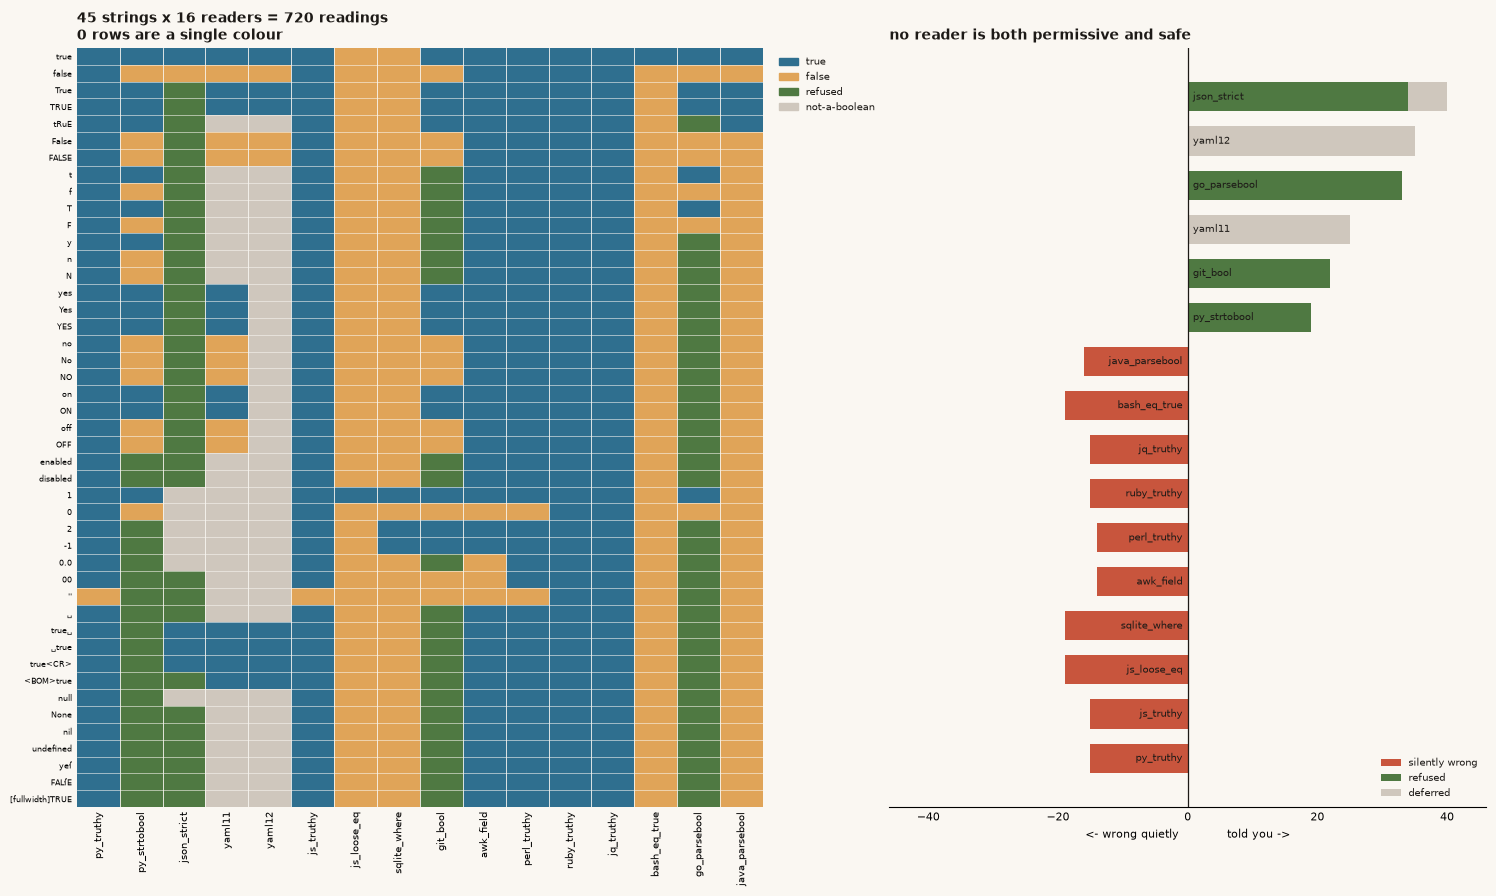

In [13]:
import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

INK, MUTED, GRIDC, PAPER = "#1d1a17", "#8a8178", "#e3ddd5", "#faf7f2"
ACCENT, COOL, WARM, GREEN = "#c8553d", "#2f6f8f", "#e0a458", "#4f7942"
COLOUR = {TRUE: COOL, FALSE: WARM, REFUSED: GREEN, NOTBOOL: "#cfc7bd"}
ORDER = [TRUE, FALSE, REFUSED, NOTBOOL]
plt.rcParams.update({"figure.facecolor": PAPER, "axes.facecolor": PAPER,
                     "text.color": INK, "font.size": 8})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 9), gridspec_kw={"width_ratios": [1.15, 1]})

idx = {v: i for i, v in enumerate(ORDER)}
data = np.array([[idx[GRID[n][j]] for n in NAMES] for j in range(len(CORPUS))])
ax1.imshow(data, cmap=matplotlib.colors.ListedColormap([COLOUR[v] for v in ORDER]),
           aspect="auto", vmin=-0.5, vmax=3.5, interpolation="nearest")
ax1.set_xticks(range(len(NAMES)))
ax1.set_xticklabels(NAMES, rotation=90, fontsize=7)
ax1.set_yticks(range(len(CORPUS)))
ax1.set_yticklabels([lab.replace("\uff34\uff32\uff35\uff25", "[fullwidth]TRUE")
                     for lab in LABELS],
                    fontsize=6)
for x in range(1, len(NAMES)):
    ax1.axvline(x - 0.5, color=PAPER, lw=0.6)
for y in range(1, len(CORPUS)):
    ax1.axhline(y - 0.5, color=PAPER, lw=0.4)
ax1.tick_params(length=0)
for s in ax1.spines.values():
    s.set_visible(False)
ax1.set_title(f"{len(CORPUS)} strings x {len(NAMES)} readers = {len(CORPUS)*len(NAMES)} readings\n"
              f"{len(unanimous)} rows are a single colour",
              loc="left", fontsize=10, fontweight="bold")
ax1.legend(handles=[mpatches.Patch(color=COLOUR[v], label=v) for v in ORDER],
           loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=7)

order = sorted(NAMES, key=lambda n: refusals[n] + deferrals[n])
y = np.arange(len(order))
span = max(max(wrong.values()), max(refusals[n] + deferrals[n] for n in order))
ax2.barh(y, [-wrong[n] for n in order], color=ACCENT, height=0.66, label="silently wrong")
ax2.barh(y, [refusals[n] for n in order], color=GREEN, height=0.66, label="refused")
ax2.barh(y, [deferrals[n] for n in order], left=[refusals[n] for n in order],
         color=COLOUR[NOTBOOL], height=0.66, label="deferred")
ax2.axvline(0, color=INK, lw=0.9)
ax2.set_yticks([])
for i, n in enumerate(order):
    left = wrong[n] > 0
    ax2.text(-span * 0.02 if left else span * 0.02, i, n,
             ha="right" if left else "left", va="center", fontsize=7.5)
ax2.set_xlim(-span * 1.15, span * 1.15)
ax2.set_xlabel("<- wrong quietly            told you ->")
for s in ("top", "right", "left"):
    ax2.spines[s].set_visible(False)
ax2.tick_params(length=0)
ax2.legend(frameon=False, fontsize=7, loc="lower right")
ax2.set_title("no reader is both permissive and safe", loc="left",
              fontsize=10, fontweight="bold")

fig.tight_layout()
fig.savefig("notebook_boolean.png", dpi=140, facecolor=PAPER)
plt.show()

## 13. Written for one reader, read by another — and it runs one way

Take the strings a given reader reads *confidently* — the spellings somebody
would plausibly write into a config authored against it — and count how many a
second reader fails to reproduce.

The matrix is **not symmetric**, and the asymmetry is the actionable part:
migrating a config from a permissive reader to a strict one breaks almost
everything, while the reverse direction is nearly free.

In [14]:
def lost(writer: str, reader: str) -> int:
    return sum(1 for a, b in zip(GRID[writer], GRID[reader]) if a in CONFIDENT and b != a)


print(f"{'A':<16} {'B':<16} {'A->B':>6} {'B->A':>6}")
print("-" * 48)
for a, b in (("py_truthy", "json_strict"), ("ruby_truthy", "go_parsebool"),
             ("js_truthy", "git_bool"), ("yaml11", "yaml12"),
             ("bash_eq_true", "py_truthy")):
    print(f"{a:<16} {b:<16} {lost(a, b):>6} {lost(b, a):>6}")

pairs = [(a, b) for a in NAMES for b in NAMES if a != b]
clean = [p for p in pairs if lost(*p) == 0]
print(f"\n{len(pairs)} ordered pairs; {len(clean)} lose nothing.")
print("Migrations have a safe direction, and it points at strictness.")

A                B                  A->B   B->A
------------------------------------------------
py_truthy        json_strict          41      1
ruby_truthy      go_parsebool         39      6
js_truthy        git_bool             32     10
yaml11           yaml12               10      0
bash_eq_true     py_truthy            43     43

240 ordered pairs; 8 lose nothing.
Migrations have a safe direction, and it points at strictness.


## 14. Try your own

Drop your own strings in and see which of your stacks disagree about them. If
you have a config file to hand, paste its actual boolean values — the interesting
ones are never `true` and `false`.

In [15]:
# MY_STRINGS = ["TRUE", "Y", "on ", "vrai", "\u662f"]
#
# import shutil, subprocess, json as _json
#
# def audit(strings):
#     rows = {}
#     rows["py_truthy"]    = [TRUE if bool(s) else FALSE for s in strings]
#     rows["json_strict"]  = live_json_strict(strings)
#     rows["sqlite_where"] = live_sqlite_where(strings)
#     rows["yaml11"]       = live_yaml11(strings)
#     rows["go_parsebool"] = live_go(strings)
#     rows["java_parsebool"] = live_java(strings)
#     if shutil.which("node"):
#         js = _json.loads(subprocess.run(
#             ["node", "-e",
#              "const xs=JSON.parse(require('fs').readFileSync(0,'utf8'));"
#              "process.stdout.write(JSON.stringify(xs.map(s=>[Boolean(s),s==true])))"],
#             input=_json.dumps(strings), capture_output=True, text=True).stdout)
#         rows["js_truthy"]   = [TRUE if a else FALSE for a, _ in js]
#         rows["js_loose_eq"] = [TRUE if b else FALSE for _, b in js]
#     return rows
#
# rows = audit(MY_STRINGS)
# print(f"{'string':<14} " + " ".join(f"{n[:11]:<12}" for n in rows))
# for i, s in enumerate(MY_STRINGS):
#     print(f"{show(s):<14} " + " ".join(f"{rows[n][i]:<12}" for n in rows))
# for i, s in enumerate(MY_STRINGS):
#     vs = {rows[n][i] for n in rows}
#     if TRUE in vs and FALSE in vs:
#         print(f"\n{show(s)!r} flips sign across your stack.")

## What to take away

A boolean reader is an **accept table**, a **normalisation** and a **failure
policy**. If you do not choose them, sixteen layers choose sixteen different
combinations on your behalf.

1. **Name the accept table in the schema**, not in the code that reads it.
   `true|false` is a defensible table. So is git's. `bool(s)` is not a table.
2. **Choose the normalisation deliberately.** Strip first — all four residue
   strings in §10 are a stripping bug — then `casefold()`, not `lower()`, and
   NFKC only if fullwidth input is possible.
3. **Refuse.** A reader that returns `false` for an unrecognised string has
   thrown away the only fact it had: that nobody knows what the value means.
   Only four of these sixteen readers can do that.

And the rule §8 earns, which is not "pick a better parser": **do not store a
boolean as text**, so that nothing downstream has to read one. A `BOOLEAN`
column, or an `INTEGER` holding 0 and 1, is never parsed. That is the whole fix.
Everything above is what it costs not to do it.

---

**Full audit:** `python evidence.py` in
[`data-engineering-pro/boolean-parser`](https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/boolean-parser) prints all sixteen
sections, and `pytest` asserts every number on this page.

**Interactive version:** `streamlit run app.py` — paste a string, see all sixteen
readers disagree about it live.

Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) — one small, real tool a day.
Days 147, 149-153 are the rest of this arc: a duration, a header name, a sort
order, a line ending, a number and a truncation, each of which turns out to be a
reader's decision rather than a property of the bytes.